# Setup

Making the necessary imports.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
from PIL import Image
import os
from neural_network_utils import GrainDataModule
import torchvision

# Exploratory Data Analysis

In this notebook, we'll take a glance at what our dataset looks like!

Lets take a quick look at some of the images of our dataset

In [6]:
data_module = GrainDataModule(data_dir="dataset/images")
data_module.setup()

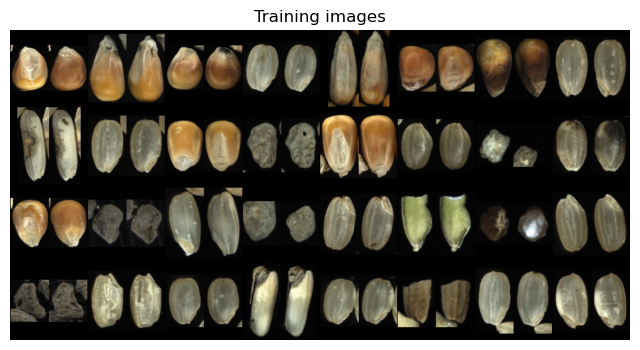

In [ ]:
for images, labels in data_module.train_dataloader():
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(
    np.transpose(
        torchvision.utils.make_grid(images[:64], padding=2, normalize=True), (1, 2, 0)
    )
)
plt.show()

## Category Distribution

Let's first see the distribution of the images for the different categories for each of the grains.

In [9]:
# Define disease categories for each grain type
MAIZE_CATEGORIES = ["0_NOR", "1_F&S", "2_SD", "3_MY", "4_AP", "5_BN", "6_HD", "7_IM"]
RICE_CATEGORIES = ["0_NOR", "1_F&S", "2_SD", "3_MY", "4_AP", "5_BN", "6_UN", "7_IM"]

CATEGORIES_MAP = {"maize": MAIZE_CATEGORIES, "rice": RICE_CATEGORIES}

# Count images in each category
base_dir = "./dataset/images"
image_distribution = {}

grain_types = ["maize", "rice"]
splits = ["train", "test"]

for grain in grain_types:
    image_distribution[grain] = {}
    categories = CATEGORIES_MAP[grain]

    for split in splits:
        split_path = os.path.join(base_dir, grain, split)

        if not os.path.exists(split_path):
            print(f"Warning: {split_path} does not exist")
            continue

        image_distribution[grain][split] = {}

        for category in categories:
            category_path = os.path.join(split_path, category)

            image_count = len(
                [f for f in os.listdir(category_path) if f.lower().endswith(".png")]
            )

            image_distribution[grain][split][category] = image_count

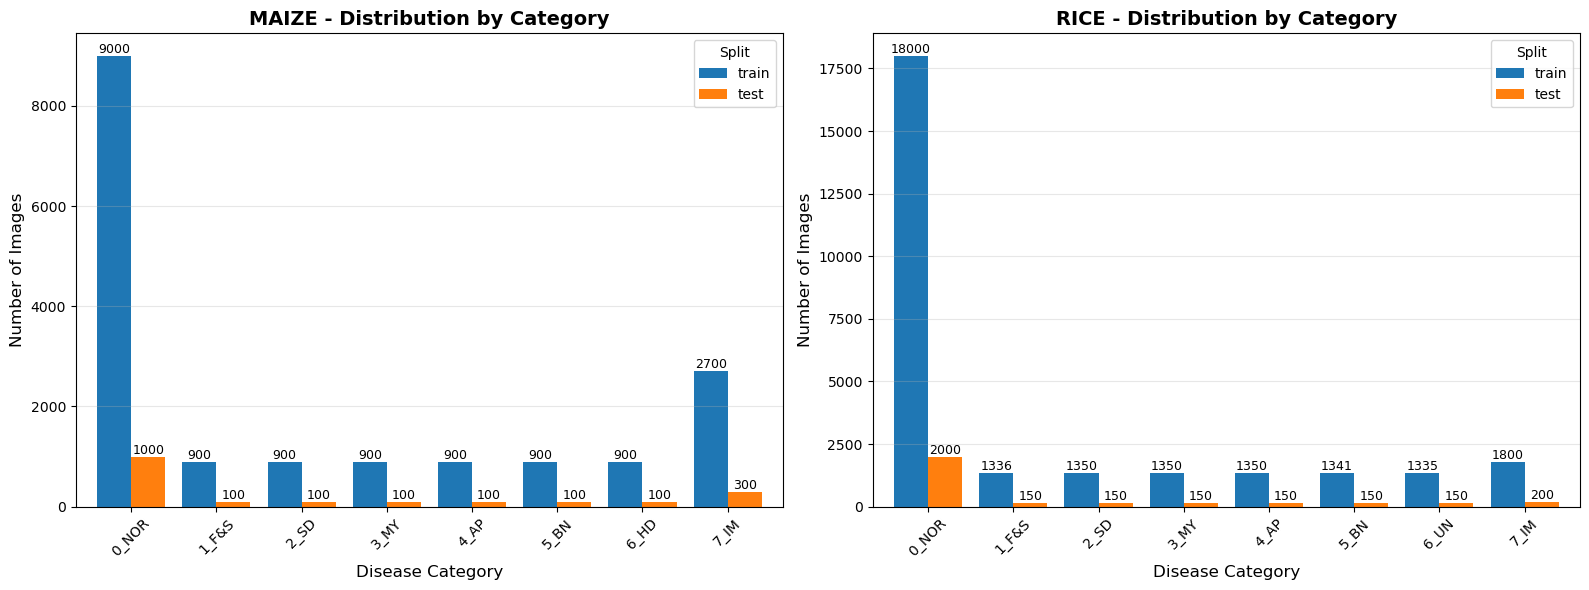

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, grain in enumerate(["maize", "rice"]):
    df = pd.DataFrame(image_distribution[grain])

    df.plot(kind="bar", ax=axes[idx], width=0.8)

    axes[idx].set_title(
        f"{grain.upper()} - Distribution by Category",
        fontsize=14,
        fontweight="bold",
    )
    axes[idx].set_xlabel("Disease Category", fontsize=12)
    axes[idx].set_ylabel("Number of Images", fontsize=12)
    axes[idx].legend(title="Split", fontsize=10)
    axes[idx].grid(axis="y", alpha=0.3)

    # Rotate x-axis labels for readability
    axes[idx].tick_params(axis="x", rotation=45)

    # Add value labels on bars
    for container in axes[idx].containers:
        axes[idx].bar_label(container, fmt="%d", fontsize=9)

plt.tight_layout()
plt.show()

## Shape and Color

The, we create a tool that can examine a single grain image and uncover its characteristics. 

This tool acts like a digital scanner that measures the grain’s dimensions and captures its average color while ignoring the dark background.

In [ ]:
def extract_grain_features_pil(img_path):
    with Image.open(img_path) as img:
        # Dimensions using bounding box of non-zero pixels
        grayscale = img.convert("L")
        bbox = grayscale.getbbox()

        if bbox:
            left, top, right, bottom = bbox
            width = right - left
            height = bottom - top
            aspect_ratio = width / height if height > 0 else 0
        else:
            width, height, aspect_ratio = 0, 0, 0

        # Calculate Average Color (RGB)
        img_rgb = img.convert("RGB")
        arr = np.array(img_rgb)
        pixels = arr.reshape(-1, 3)

        # Filter background
        mask = np.any(pixels > 20, axis=1)
        foreground = pixels[mask]

        if len(foreground) > 0:
            mean_color = foreground.mean(axis=0)
        else:
            mean_color = [0, 0, 0]

        return {
            "width": width,
            "height": height,
            "aspect_ratio": aspect_ratio,
            "mean_r": mean_color[0],
            "mean_g": mean_color[1],
            "mean_b": mean_color[2],
        }

Once the scanner is ready, we apply it to the dataset in a systematic way. 

Rather than analyzing every image, we perform a statistical survey by sampling 300 images from each category. 

This approach provides enough data to reveal meaningful patterns while keeping the analysis efficient.

In [ ]:
features_list = []
# Sample 300 images from each category for the analysis
sample_size = 300

for grain in ["maize", "rice"]:
    categories = CATEGORIES_MAP[grain]
    for cat in categories:
        path = os.path.join(base_dir, grain, "train", cat)
        if not os.path.exists(path):
            continue

        images = [f for f in os.listdir(path) if f.lower().endswith(".png")]
        sample = random.sample(images, min(len(images), sample_size))

        for img_name in sample:
            img_path = os.path.join(path, img_name)
            stats = extract_grain_features_pil(img_path)
            stats.update({"grain": grain, "category": cat})
            features_list.append(stats)

feat_df = pd.DataFrame(features_list)

## Effects of Disease

Finally, we visualize the data to answer key questions:

- Does the disease change the shape of the kernel?
- Does the disease change the color of the kernel?

**Intuition:** If we see clear distinctions in these graphs, we know our Machine Learning model will likely perform well.

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


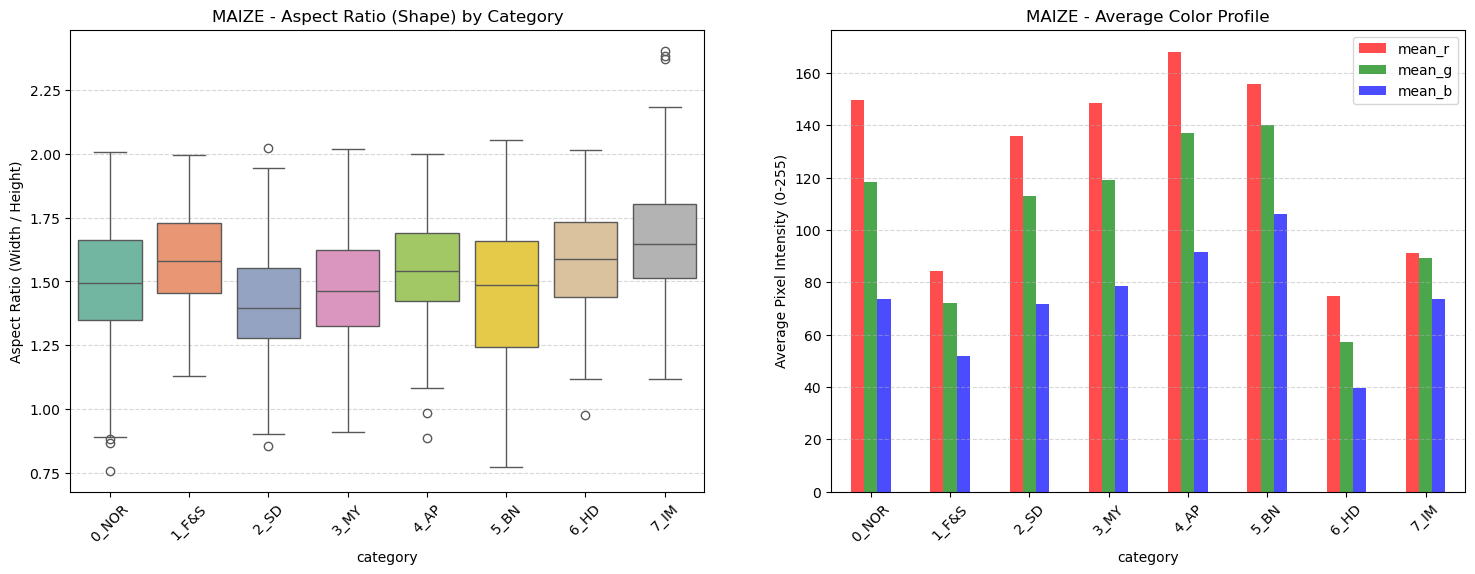

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


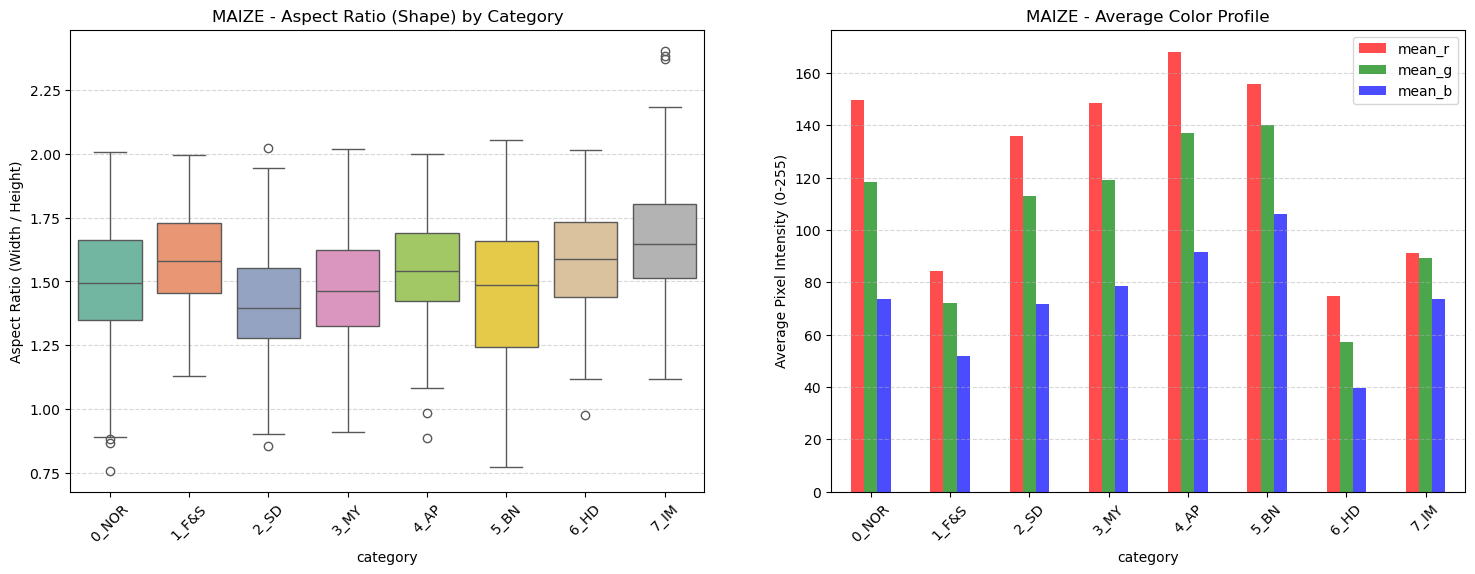

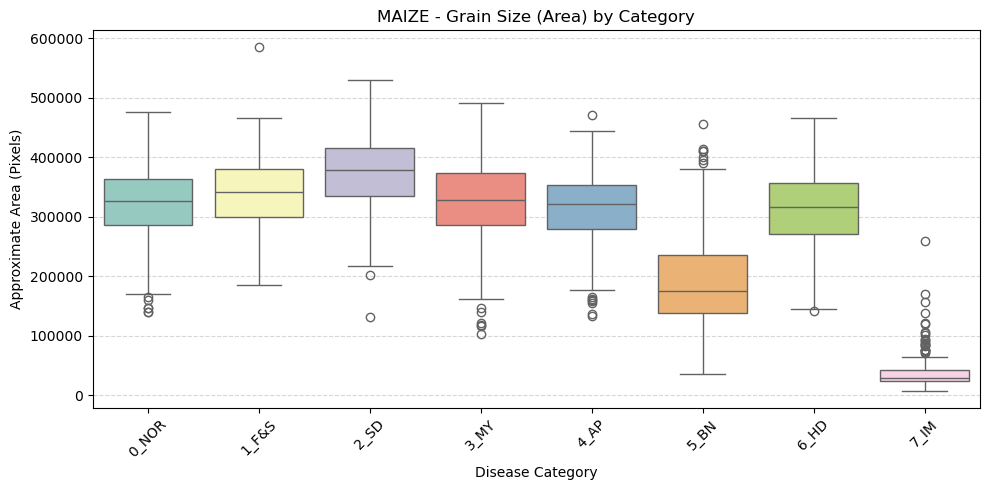

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


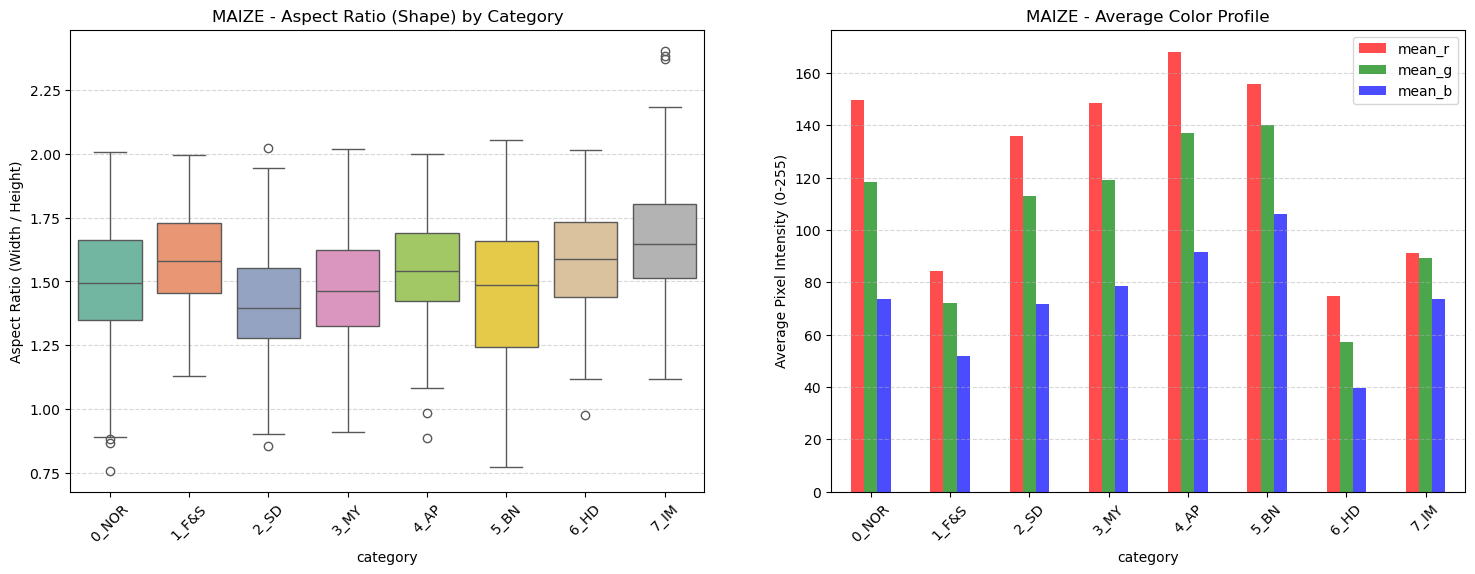

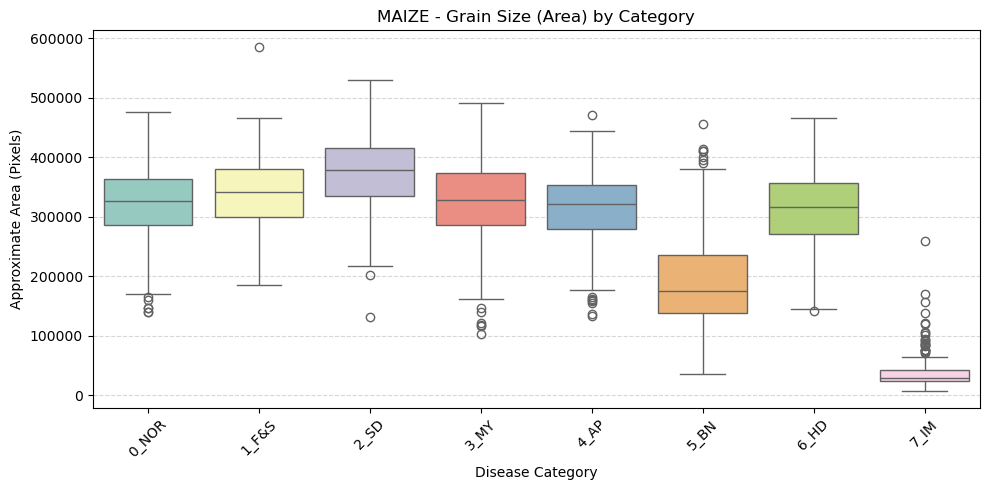

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


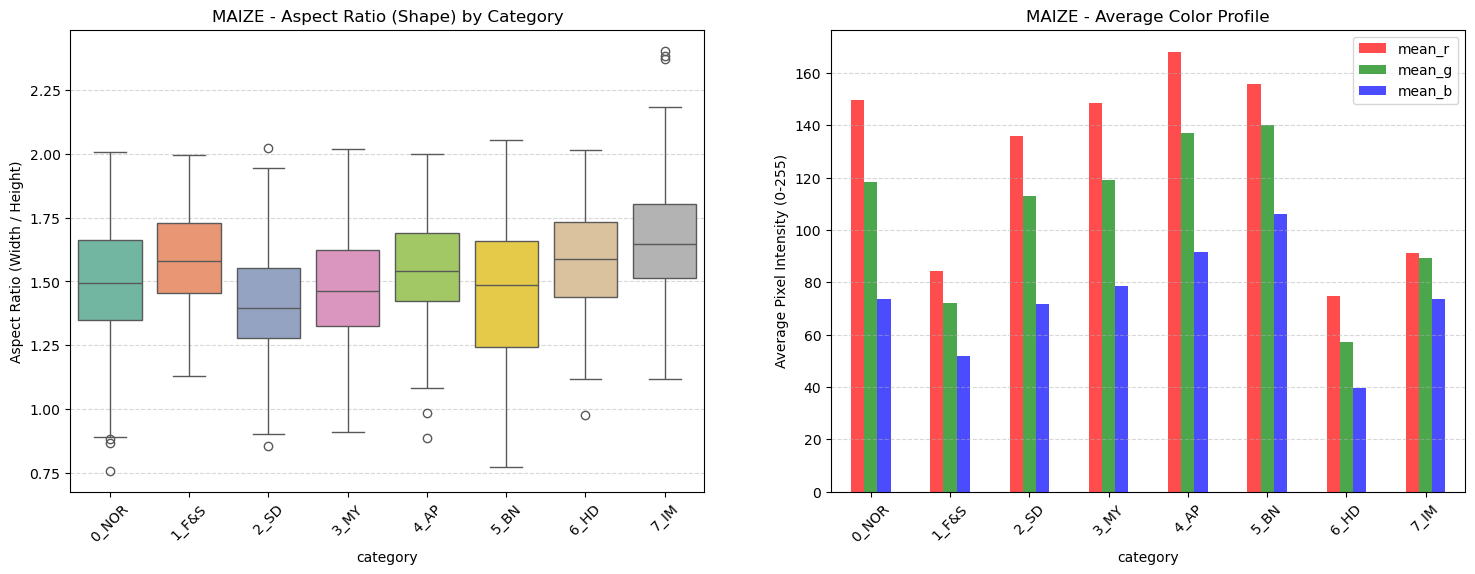

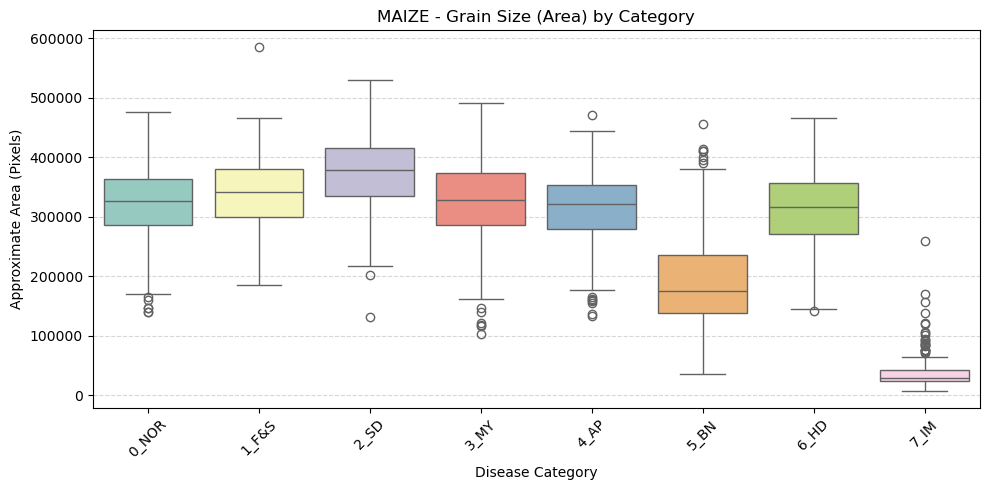

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


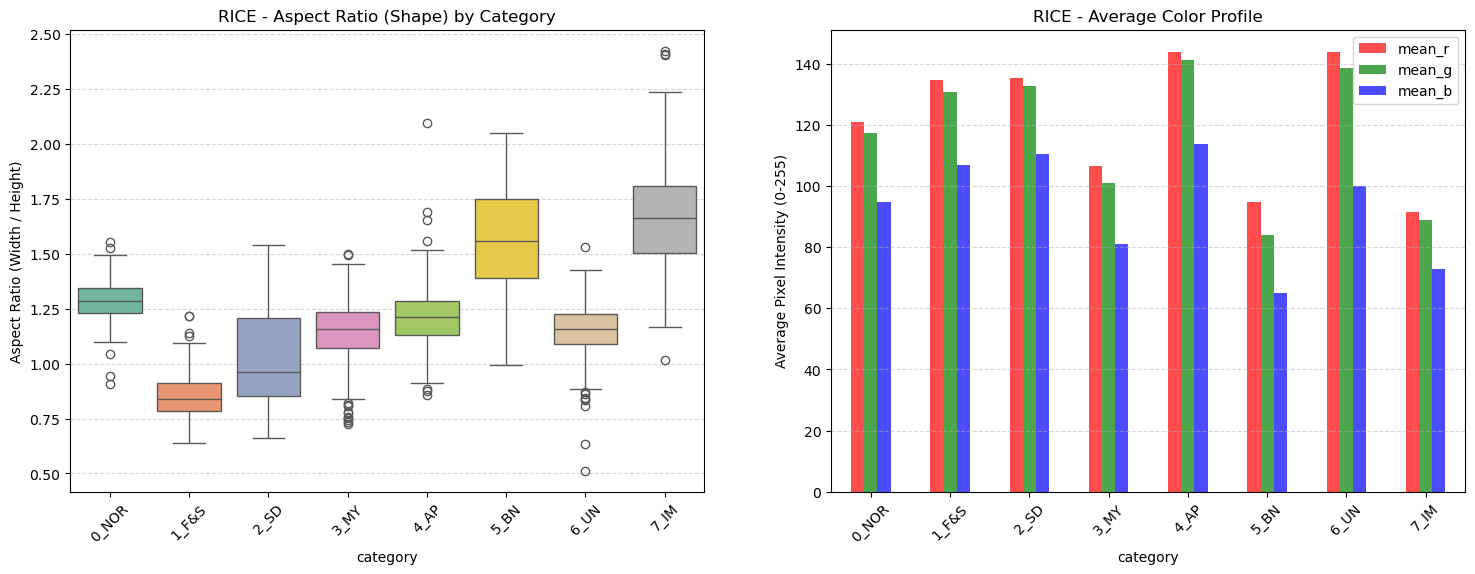

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


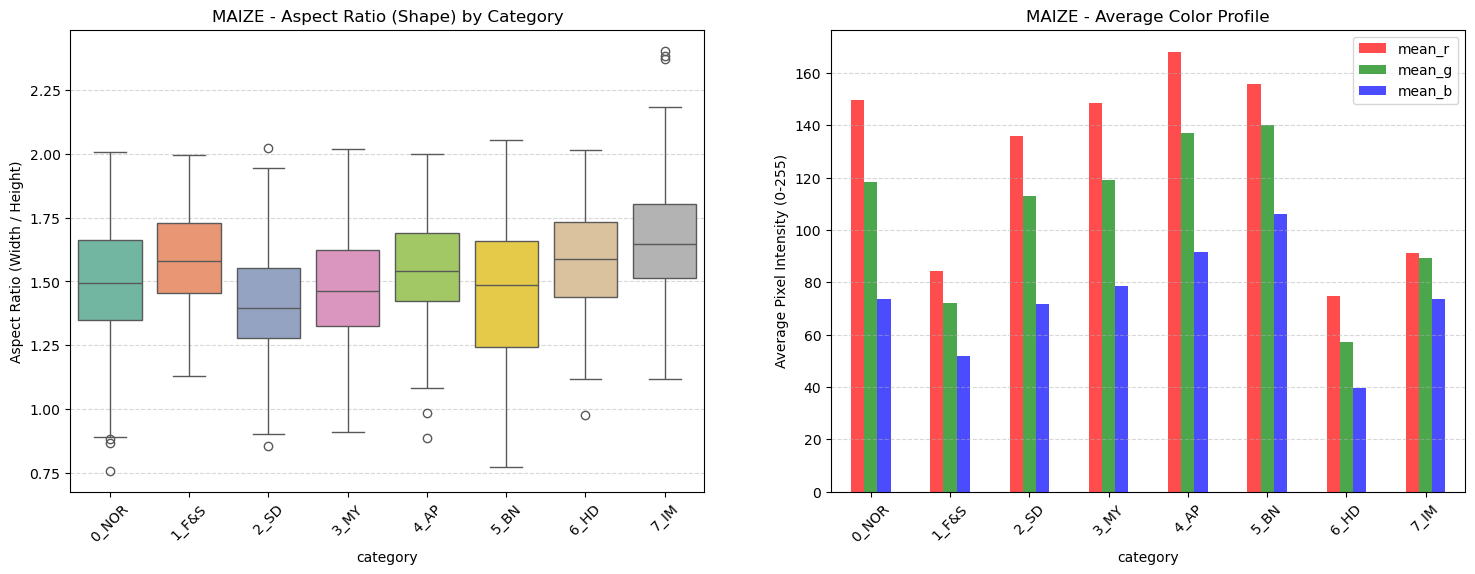

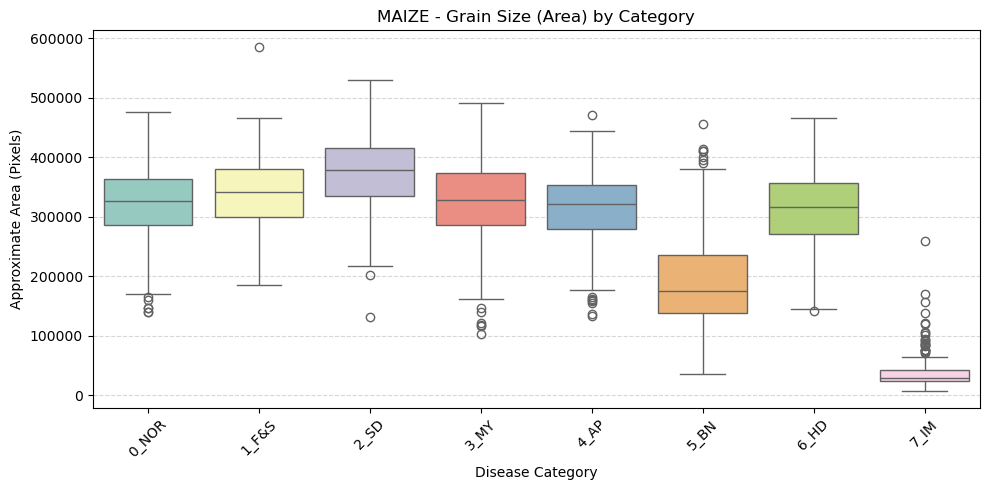

/tmp/ipykernel_22298/1702459765.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='aspect_ratio', ax=axes[0], palette="Set2")
/tmp/ipykernel_22298/1702459765.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=grain_data, x='category', y='area', palette="Set3")


--------------------------------------------------------------------------------


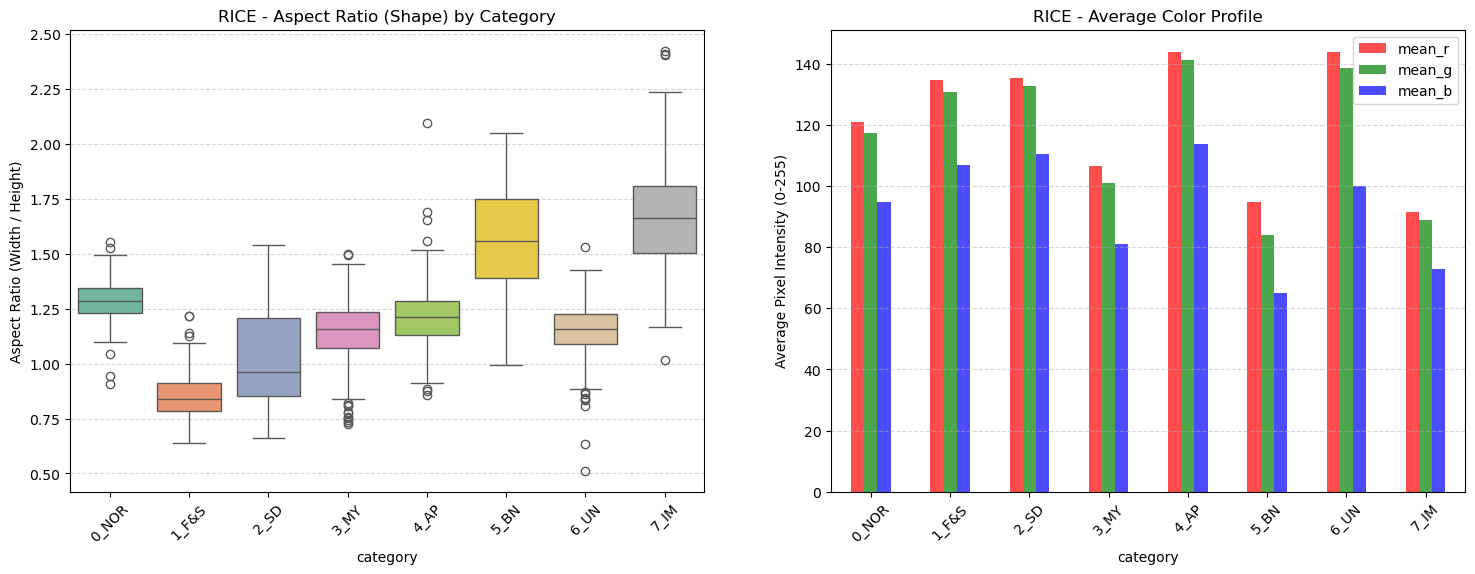

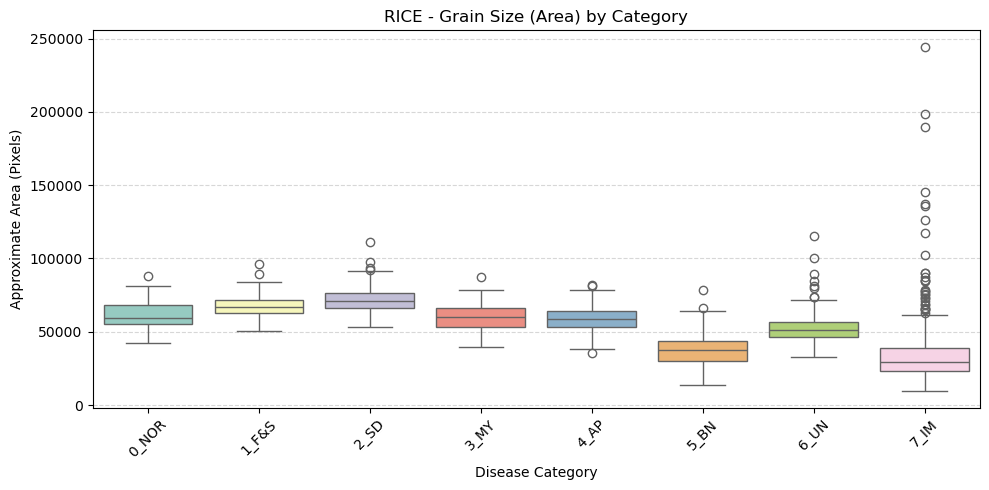

In [ ]:
# Calculate area of the size of the grain
feat_df["area"] = feat_df["width"] * feat_df["height"]

for grain in ["maize", "rice"]:
    grain_data = feat_df[feat_df["grain"] == grain]
    if grain_data.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # We use a boxplot to see if diseases cause the grain to shrivel or deform
    sns.boxplot(
        data=grain_data, x="category", y="aspect_ratio", ax=axes[0], palette="Set2"
    )
    axes[0].set_title(f"{grain.upper()} - Aspect Ratio (Shape) by Category")
    axes[0].set_ylabel("Aspect Ratio (Width / Height)")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    # Average Red, Green, and Blue intensity
    color_stats = grain_data.groupby("category")[["mean_r", "mean_g", "mean_b"]].mean()
    color_stats.plot(kind="bar", ax=axes[1], color=["red", "green", "blue"], alpha=0.7)
    axes[1].set_title(f"{grain.upper()} - Average Color Profile")
    axes[1].set_ylabel("Average Pixel Intensity (0-255)")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

    # Size of the grains
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=grain_data, x="category", y="area", palette="Set3")
    plt.title(f"{grain.upper()} - Grain Size (Area) by Category")
    plt.ylabel("Approximate Area (Pixels)")
    plt.xlabel("Disease Category")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    print("-" * 80)

    plt.tight_layout()
    plt.show()

## In Summary

The dataset reveals distinct physical and chromatic patterns across both grain categories, confirming that the data contains separable features suitable for machine learning classification.

### Maize
Aspect ratios remain fairly consistent (medians $\approx$ 1.5) across categories, though diseased classes exhibit significant outlier spread which indicates shape irregularity. Grain size proves to be a stronger discriminator, with Immature (IM) and Broken (BN) grains showing drastically reduced areas compared to the stable dimensions of other groups. Chromatically, maize categories are clearly distinguishable, as Heat Damaged (HD), Fusarium (F&S), and Impurities (IM) samples appear noticeably darker.

### Rice
Aspect ratios vary more distinctly due to differences in elongation. Color profiling successfully isolates darker Moldy (MY), Broken (BN), and Impurities (IM) grains from brighter categories like Unripe (UN). These distinct geometric and chromatic patterns confirm that the dataset contains separable features suitable for robust classification.